# 04 — Default probability: a model you can defend line by line

Notebooks 02 and 03 measured loss. This one predicts it, at the level of a
single loan: given only what was knowable on the day the loan was funded, what
is the probability it charges off?

**The headline model is a logistic regression, and that is a deliberate choice
rather than a limitation.** A PD model in production has to be explained to a
credit committee, defended to a model-risk function, and — under fair-lending
rules — turned into a specific adverse-action reason when an applicant is
declined. A model whose coefficients cannot be read aloud fails those tests
regardless of its AUC.

The gradient-boosted model at the end exists to answer one question honestly:
**how much accuracy does that interpretability actually cost?** If the answer is
"very little," the interpretable model wins on every other dimension.

### Two design choices worth stating up front

**1. Out-of-time validation, not a random split.** A random split lets the model
train on 2016 loans and be tested on other 2016 loans — but that is not the job.
The job is to underwrite loans that have not been written yet. So we train on
vintages through 2014 and test on 2015–2016: the model is scored on cohorts
originated *after* everything it learned from. Notebook 02 showed those cohorts
were materially worse, which makes this a genuinely hard test — and a realistic
one.

**2. No LendingClub grade in the headline model.** The grade is known at
origination, so using it would not be leakage. But it is the lender's own risk
assessment; a model built on it substantially re-learns LC's pricing engine
rather than the underlying credit. We fit borrower attributes first, then add
the grade as a labeled comparison to size how much signal the lender had already
extracted.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src import data_prep as dp  # noqa: E402
from src import plotting as pl  # noqa: E402

pl.set_style()
RANDOM_STATE = 42

df = pd.read_parquet(dp.PROCESSED)
df = df[df["fico_band"] != "<660"].copy()
print(f"Loans available: {len(df):,}")
print(f"Base charge-off rate: {df['charged_off'].mean():.2%}")

Loans available: 732,627
Base charge-off rate: 14.94%


## The train / test split

In [2]:
TRAIN_THROUGH = 2014

train_mask = df["vintage_year"] <= TRAIN_THROUGH
test_mask = df["vintage_year"] > TRAIN_THROUGH

split_summary = pd.DataFrame(
    {
        "Loans": [train_mask.sum(), test_mask.sum()],
        "Vintages": [
            f"{df.loc[train_mask, 'vintage_year'].min()}–{TRAIN_THROUGH}",
            f"{TRAIN_THROUGH + 1}–{df.loc[test_mask, 'vintage_year'].max()}",
        ],
        "Funded ($B)": [
            df.loc[train_mask, "funded_amnt"].sum() / 1e9,
            df.loc[test_mask, "funded_amnt"].sum() / 1e9,
        ],
        "Charge-off rate": [
            df.loc[train_mask, "charged_off"].mean(),
            df.loc[test_mask, "charged_off"].mean(),
        ],
    },
    index=["Train", "Test"],
).round(3)
split_summary

,Loans,Vintages,Funded ($B),Charge-off rate
Train,398906,2007–2014,5.345,0.150
Test,333721,2015–2016,4.320,0.149


Note the charge-off rates: the test period is **worse than the training
period**. That is not a flaw in the split — it is the situation every credit
model is actually deployed into, and it is exactly what makes the calibration
check further down interesting.

In [3]:
X_all, reference_levels = dp.feature_matrix(df, return_reference_levels=True)
X_all_grade = dp.feature_matrix(df, include_grade=True)
y_all = df["charged_off"].values

# Categorical coefficients are read *relative to* a baseline level. Making that
# baseline the most common level -- rather than whatever sorts first -- is what
# lets each coefficient be stated as "compared with the typical borrower."
print("Reference (baseline) level for each categorical:")
for col, ref in reference_levels.items():
    print(f"  {col:<22} {ref}")
print()


def drop_train_constant(X: pd.DataFrame, mask: pd.Series) -> pd.DataFrame:
    """
    Remove one-hot columns that never fire in the training window.

    An out-of-time split can hand you a category that simply did not exist
    earlier: LendingClub only began accepting joint applications in 2015, so
    `application_type_Joint App` is all zeros before the split date. Such a
    column carries no information to estimate from, and it makes the design
    matrix singular the moment you ask statsmodels for standard errors.

    Dropping it is the honest response. The alternative -- letting the model
    assign a coefficient to a feature it has never seen vary -- is how you end up
    extrapolating a number nobody can defend.
    """
    constant = X[mask].std(axis=0) == 0
    if constant.any():
        print("Dropped (no variation in the training window):")
        for c in X.columns[constant]:
            print(f"  · {c}")
    return X.loc[:, ~constant]


X_all = drop_train_constant(X_all, train_mask)
X_all_grade = drop_train_constant(X_all_grade, train_mask)

X_train, X_test = X_all[train_mask], X_all[test_mask]
Xg_train, Xg_test = X_all_grade[train_mask], X_all_grade[test_mask]
y_train, y_test = y_all[train_mask], y_all[test_mask]

print()
print(f"Design matrix: {X_all.shape[1]} columns after one-hot encoding")
print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")

Reference (baseline) level for each categorical:
  home_ownership         MORTGAGE
  verification_status    Source Verified
  purpose                debt_consolidation
  application_type       Individual



Dropped (no variation in the training window):
  · application_type_OTHER


Dropped (no variation in the training window):
  · application_type_OTHER



Design matrix: 30 columns after one-hot encoding
Train: 398,906 rows   Test: 333,721 rows


## Model 1 — Logistic regression on borrower attributes

The pipeline is three steps and no more: median-impute the handful of missing
values, standardise so coefficients are comparable across features on different
scales, then fit. No feature selection, no interactions, no transformations
beyond the log-income term already built in notebook 01. Every step is here
because it is necessary, which is the standard a model-risk reviewer applies.

In [4]:
logit = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
    ]
)
logit.fit(X_train, y_train)

p_logit = logit.predict_proba(X_test)[:, 1]
auc_logit = roc_auc_score(y_test, p_logit)
print(f"Logistic (borrower features only) — out-of-time AUC: {auc_logit:.4f}")

Logistic (borrower features only) — out-of-time AUC: 0.6570


## What the model learned

This is the section the whole notebook exists for. Refit with `statsmodels` on
the standardised features so we get standard errors and p-values alongside the
coefficients, then read them.

Because the inputs are standardised, each coefficient answers a directly
comparable question: **"if this feature moves one standard deviation, what
happens to the log-odds of default, holding everything else fixed?"** Exponentiate
it and you get an odds ratio, which is the form a credit committee will want.

In [5]:
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler = StandardScaler().fit(imputer.transform(X_train))

X_train_std = scaler.transform(imputer.transform(X_train))
X_train_sm = sm.add_constant(pd.DataFrame(X_train_std, columns=X_train.columns))

sm_logit = sm.Logit(y_train, X_train_sm).fit(disp=0)

coefs = pd.DataFrame(
    {
        "Coefficient": sm_logit.params,
        "Std error": sm_logit.bse,
        "z": sm_logit.tvalues,
        "p-value": sm_logit.pvalues,
        "Odds ratio per 1 SD": np.exp(sm_logit.params),
    }
).drop(index="const")

coefs["abs"] = coefs["Coefficient"].abs()
coefs = coefs.sort_values("abs", ascending=False).drop(columns="abs")
coefs.round(4).head(20)

,Coefficient,Std error,z,p-value,Odds ratio per 1 SD
fico_score,-0.3327,0.0066,-50.6356,0.0000,0.7170
log_annual_inc,-0.2864,0.0066,-43.0789,0.0000,0.7510
term_months,0.2748,0.0045,61.6558,0.0000,1.3163
loan_amnt,0.1942,0.0064,30.3505,0.0000,1.2143
inq_last_6mths,0.1629,0.0044,36.9323,0.0000,1.1770
dti,0.1122,0.0053,21.0144,0.0000,1.1187
purpose_small_business,0.0986,0.0039,25.3418,0.0000,1.1036
open_acc,0.0947,0.0067,14.1637,0.0000,1.0994
purpose_credit_card,-0.0881,0.0050,-17.7157,0.0000,0.9156
home_ownership_RENT,0.0823,0.0056,14.7170,0.0000,1.0858


### The coefficient chart

Sign is carried by a diverging blue↔red scale: **red pushes default risk up,
blue pushes it down.** Bar length is the size of the effect per one-standard-
deviation move.

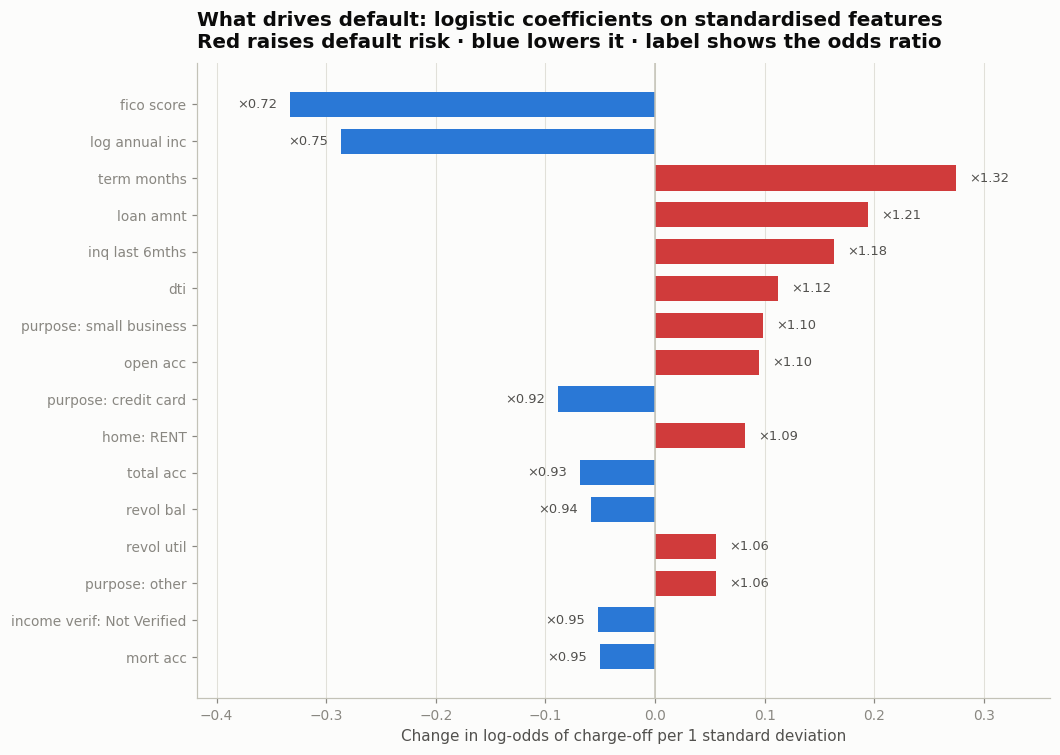

In [6]:
top = coefs.head(16).iloc[::-1]
labels = [
    c.replace("purpose_", "purpose: ")
    .replace("home_ownership_", "home: ")
    .replace("verification_status_", "income verif: ")
    .replace("application_type_", "application: ")
    .replace("_", " ")
    for c in top.index
]

fig, ax = plt.subplots(figsize=(10, 7.5))
colors = [pl.STATUS_CRITICAL if v > 0 else pl.CATEGORICAL[0] for v in top["Coefficient"]]
bars = ax.barh(labels, top["Coefficient"], color=colors, height=0.68)

for b, v, orr in zip(bars, top["Coefficient"], top["Odds ratio per 1 SD"]):
    offset = 0.012 if v > 0 else -0.012
    ax.text(
        v + offset, b.get_y() + b.get_height() / 2,
        f"×{orr:.2f}", va="center", ha="left" if v > 0 else "right",
        fontsize=8.5, color=pl.INK_SECONDARY,
    )

ax.axvline(0, color=pl.AXISLINE, linewidth=1)
ax.set_xlabel("Change in log-odds of charge-off per 1 standard deviation")
ax.set_title(
    "What drives default: logistic coefficients on standardised features\n"
    "Red raises default risk · blue lowers it · label shows the odds ratio",
    loc="left",
)
pl.style_axes(ax, xgrid=True, ygrid=False)
ax.margins(x=0.14)

pl.save_fig(fig, "04_coefficients.png")
plt.show()

### Reading it out loud

Six effects dominate, and every one of them is something a human underwriter
would recognise:

* **FICO is the strongest single feature** (odds ratio 0.72 per standard
  deviation). One SD is roughly 32 points of score, and moving up that much cuts
  default odds by about 28%. The bureau score earns its place.
* **Income lowers risk almost as much as FICO** (0.75 per SD). Capacity to pay
  is nearly as informative as credit history — which is the argument for
  collecting and verifying it.
* **Term is the strongest risk-*increasing* feature** (1.32 per SD). Part is
  genuine duration risk — five years is more time for circumstances to break —
  and part is selection: borrowers who need the smaller monthly payment a
  60-month term provides are on average more stretched to begin with. That
  selection reading is why term cannot simply be priced as duration.
* **Loan size raises risk** (1.21), independently of income and DTI. Bigger
  commitments are harder to service through a shock.
* **Recent credit inquiries raise risk** (1.18). A borrower shopping for credit
  in the last six months is a borrower under pressure — the classic
  credit-seeking signal, and it survives controlling for the score.
* **Stated purpose carries real signal.** Relative to debt consolidation (the
  baseline), small-business borrowing is meaningfully riskier and credit-card
  refinancing is meaningfully safer. A borrower consolidating card debt at a
  lower rate is doing something economically sensible; someone funding a small
  business with unsecured personal credit is taking business risk on a consumer
  balance sheet.

Nothing has the wrong sign, and nothing needs a footnote to justify. That
property — every coefficient defensible, out loud, without a tool — is what is
being bought.

**One caution on causal reading.** These are associations in a model with 30
correlated inputs, not causal effects. "Renting raises default odds 8% versus
holding a mortgage" is a statement about what renting *predicts* in this
population; homeowners differ from renters in wealth, age and stability, and the
coefficient absorbs whatever of that the other features do not already capture.
The model is a good ranker and a poor experiment, and it should be described
that way.

## Model 2 — the same regression, plus LendingClub's grade

How much of the signal had the lender already extracted?

In [7]:
logit_grade = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
    ]
)
logit_grade.fit(Xg_train, y_train)
p_logit_grade = logit_grade.predict_proba(Xg_test)[:, 1]
auc_logit_grade = roc_auc_score(y_test, p_logit_grade)

print(f"Logistic + LC grade — out-of-time AUC: {auc_logit_grade:.4f}")
print(f"Lift over borrower-only:              {auc_logit_grade - auc_logit:+.4f}")

Logistic + LC grade — out-of-time AUC: 0.6844
Lift over borrower-only:              +0.0274


## Model 3 — gradient boosting, as a benchmark only

LightGBM on exactly the same borrower features. No tuning theatre: shallow
trees, a modest learning rate, early stopping on a held-out slice of the
training data. The purpose is to measure the ceiling that a flexible model
reaches on this feature set, not to win a leaderboard.

In [8]:
val_cut = int(len(X_train) * 0.85)
lgb_train = lgb.Dataset(X_train.iloc[:val_cut], label=y_train[:val_cut])
lgb_val = lgb.Dataset(X_train.iloc[val_cut:], label=y_train[val_cut:])

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,       # shallow: this is a benchmark, not a Kaggle entry
    "min_data_in_leaf": 200,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": RANDOM_STATE,
}

booster = lgb.train(
    params,
    lgb_train,
    num_boost_round=1200,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

p_gbm = booster.predict(X_test, num_iteration=booster.best_iteration)
auc_gbm = roc_auc_score(y_test, p_gbm)
print(f"LightGBM (borrower features only) — out-of-time AUC: {auc_gbm:.4f}")
print(f"Boosting rounds used: {booster.best_iteration}")

LightGBM (borrower features only) — out-of-time AUC: 0.6751
Boosting rounds used: 395


## The comparison

Alongside AUC, two metrics that credit teams actually use:

* **KS statistic** — the maximum vertical gap between the cumulative
  distributions of good and bad loans. It is the standard rank-ordering measure
  on a credit scorecard, and it answers "how cleanly does the score separate the
  two populations?"
* **Brier score** — mean squared error of the predicted probabilities. Unlike
  AUC it punishes miscalibration, so it catches a model that ranks well but
  states the wrong level. Lower is better.

In [9]:
def ks_statistic(y_true, y_score):
    """Maximum separation between the good and bad score distributions."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))


models = {
    "Logistic — borrower only": p_logit,
    "Logistic + LC grade": p_logit_grade,
    "LightGBM — borrower only": p_gbm,
}

comparison = pd.DataFrame(
    {
        "AUC": {k: roc_auc_score(y_test, v) for k, v in models.items()},
        "KS": {k: ks_statistic(y_test, v) for k, v in models.items()},
        "Brier": {k: brier_score_loss(y_test, v) for k, v in models.items()},
    }
).round(4)
comparison["AUC vs logistic"] = (comparison["AUC"] - comparison.loc["Logistic — borrower only", "AUC"]).round(4)
comparison

,AUC,KS,Brier,AUC vs logistic
Logistic — borrower only,0.6570,0.2264,0.1221,0.0000
Logistic + LC grade,0.6844,0.2696,0.1204,0.0274
LightGBM — borrower only,0.6751,0.2524,0.1207,0.0181


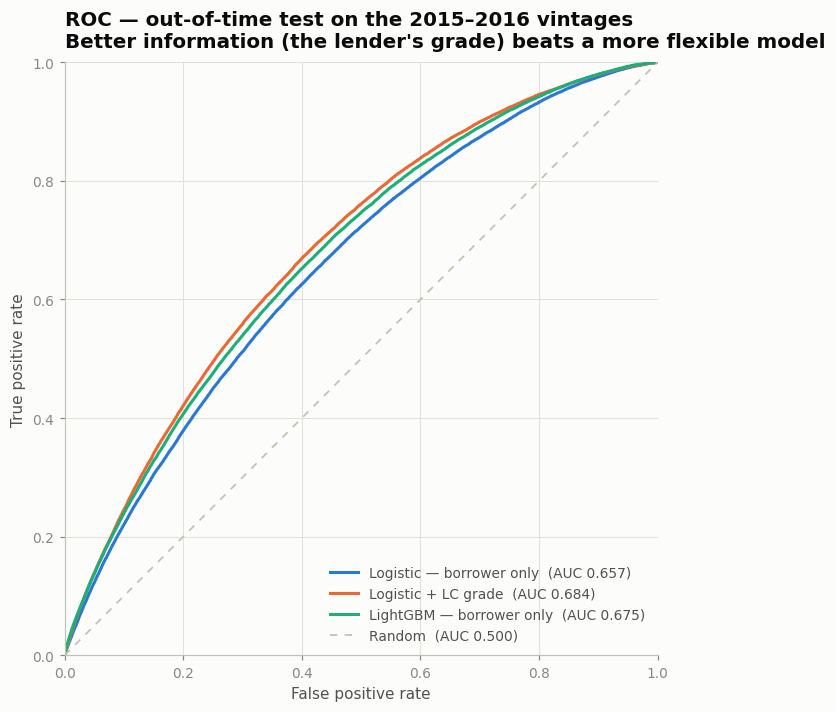

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 7))

for (name, p), color in zip(models.items(), pl.CATEGORICAL[:3]):
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=color, label=f"{name}  (AUC {roc_auc_score(y_test, p):.3f})")

ax.plot([0, 1], [0, 1], color=pl.AXISLINE, linewidth=1.2, linestyle=(0, (4, 4)),
        label="Random  (AUC 0.500)")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(
    "ROC — out-of-time test on the 2015–2016 vintages\n"
    "Better information (the lender's grade) beats a more flexible model",
    loc="left",
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
pl.style_axes(ax, xgrid=True, ygrid=True)
ax.legend(loc="lower right")

pl.save_fig(fig, "04_roc_curves.png")
plt.show()

### The honest read on logistic vs boosted

**LightGBM beats the logistic regression by +0.018 AUC (0.657 → 0.675) on the
same features.** That is a real gap, not a rounding error, and it should not be
waved away — a flexible model is finding some interaction structure the linear
form misses.

It is also small in the terms that matter. Both models are being asked to rank
loans for a cutoff or a pricing tier, and 0.018 of AUC moves few loans across
any threshold a lender would actually set. Meanwhile:

| | Logistic | LightGBM |
|---|---|---|
| Out-of-time AUC | 0.657 | 0.675 |
| Coefficient you can read aloud | yes | no |
| Adverse-action reason codes | direct | needs a post-hoc explainer |
| Model-risk review | straightforward | substantially heavier |
| Behaviour outside the training range | predictable | not guaranteed |

The sharper result is the third row of the comparison table. **Adding
LendingClub's own grade to the logistic model (0.684) beats the boosted model on
borrower features alone (0.675).** Better information beat a better function
form — which is the usual answer in credit, and the reason underwriting teams
spend their budget on data rather than on architecture.

Why is the boosted gain modest? Consumer credit risk expressed in bureau
variables is mostly *monotone and smooth*: more income is better, higher DTI is
worse, more recent inquiries are worse, all the way along. A linear model in
log-odds space fits that shape well, so flexibility has less left to find than
it would on a problem with genuine threshold effects.

**The production call is the logistic model, and it is a judgement rather than a
limitation.** The boosted model earns its place as a *challenger*: run it
alongside, and if the gap ever widens materially, that is evidence of structure
the scorecard is missing and a signal to go looking for it.

## Calibration: does the model state the right *level*?

AUC only measures ordering. A model can rank loans perfectly and still be
systematically wrong about the absolute probability — and for portfolio loss
modeling, the level is the thing that matters, because expected loss is a sum of
probabilities, not of ranks.

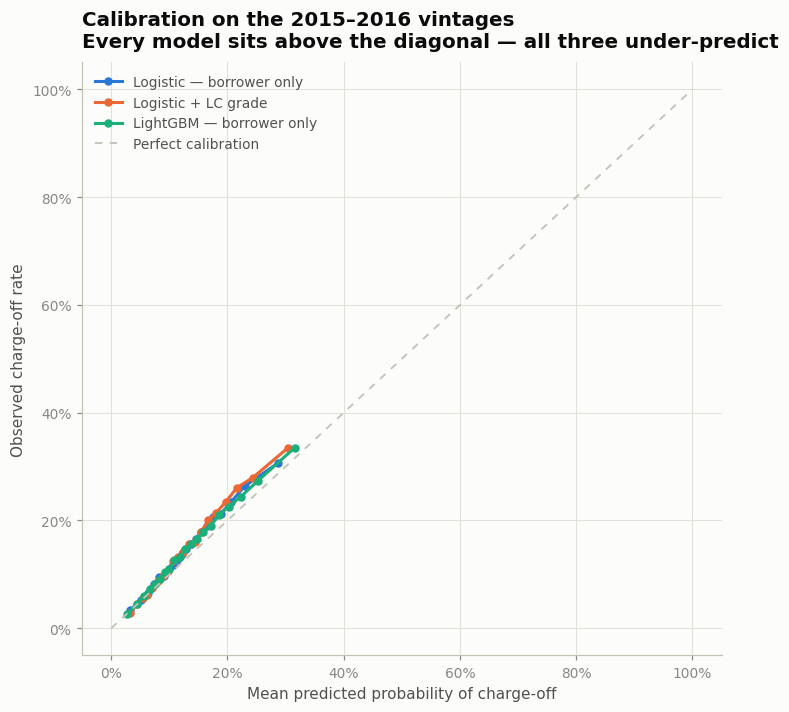

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 7))

for (name, p), color in zip(models.items(), pl.CATEGORICAL[:3]):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac_pos, color=color, marker="o", markersize=4.5, label=name)

lims = [0, max(0.6, float(np.nanmax(p_logit)))]
ax.plot(lims, lims, color=pl.AXISLINE, linewidth=1.2, linestyle=(0, (4, 4)),
        label="Perfect calibration")

ax.set_xlabel("Mean predicted probability of charge-off")
ax.set_ylabel("Observed charge-off rate")
ax.set_title(
    "Calibration on the 2015–2016 vintages\n"
    "Every model sits above the diagonal — all three under-predict",
    loc="left",
)
pl.pct_axis(ax, "x", decimals=0)
pl.pct_axis(ax, "y", decimals=0)
pl.style_axes(ax, xgrid=True, ygrid=True)
ax.legend(loc="upper left")

pl.save_fig(fig, "04_calibration.png")
plt.show()

In [12]:
print(f"Predicted mean PD on test set: {p_logit.mean():.2%}")
print(f"Actual charge-off rate:        {y_test.mean():.2%}")
print(f"Under-prediction:              {y_test.mean() - p_logit.mean():+.2%} points")
print(f"                               ({y_test.mean() / p_logit.mean() - 1:+.1%} relative)")

Predicted mean PD on test set: 13.26%
Actual charge-off rate:        14.88%
Under-prediction:              +1.62% points
                               (+12.2% relative)


**The model under-predicts default on the out-of-time test, and this is the most
instructive result in the notebook.**

It is not a bug. It is notebook 02 showing up in the model: the 2015–2016
vintages were genuinely worse than the 2007–2014 book the model was trained on,
at the same observable borrower characteristics. A model fit on the old
relationship cannot know that the same 700-FICO borrower became riskier — nothing
in the feature set says so.

This is precisely why credit models in production are **recalibrated frequently
and refit rarely**. The rank-ordering — which loans are riskier than which — is
stable and transfers out of time. The level drifts with the credit cycle, the
lender's own standards, and the macro environment, and has to be reset against
recent performance. Reporting the level as though it were fixed is how a loss
forecast quietly goes wrong.

The reinsurance analogy is exact: your relativities hold up, but the base rate
has moved and needs to be trended.

## The decile lift table

The form a credit team actually reviews. Score the test set, sort by predicted
PD, cut into ten equal buckets, and check that observed loss climbs monotonically
with predicted risk. This is the practical test of whether a score is usable for
a cutoff or a pricing tier.

In [13]:
test_df = df.loc[test_mask].copy()
test_df["pd_pred"] = p_logit
test_df["decile"] = pd.qcut(test_df["pd_pred"], 10, labels=range(1, 11))

lift = test_df.groupby("decile", observed=True).agg(
    Loans=("charged_off", "size"),
    Mean_PD=("pd_pred", "mean"),
    Actual_rate=("charged_off", "mean"),
    Funded_M=("funded_amnt", lambda s: s.sum() / 1e6),
    Net_loss_M=("net_chargeoff", lambda s: s.sum() / 1e6),
)
lift["Net loss rate"] = lift["Net_loss_M"] / lift["Funded_M"]
lift["Lift vs book"] = lift["Actual_rate"] / y_test.mean()

lift_fmt = lift.copy()
for c in ["Mean_PD", "Actual_rate", "Net loss rate"]:
    lift_fmt[c] = (lift_fmt[c] * 100).round(1).astype(str) + "%"
lift_fmt["Funded_M"] = lift_fmt["Funded_M"].round(0).astype(int)
lift_fmt["Net_loss_M"] = lift_fmt["Net_loss_M"].round(1)
lift_fmt["Lift vs book"] = lift_fmt["Lift vs book"].round(2)
lift_fmt.columns = ["Loans", "Predicted PD", "Actual rate", "Funded ($M)",
                    "Net loss ($M)", "Net loss rate", "Lift vs book"]
lift_fmt

,Loans,Predicted PD,Actual rate,Funded ($M),Net loss ($M),Net loss rate,Lift vs book
decile,,,,,,,
1,33373,4.2%,4.3%,491,10.4,2.1%,0.29
2,33372,6.9%,7.4%,467,15.7,3.4%,0.50
3,33372,8.7%,9.6%,451,20.4,4.5%,0.64
4,33372,10.2%,11.3%,442,25.2,5.7%,0.76
5,33372,11.7%,13.2%,433,27.9,6.5%,0.89
6,33372,13.3%,15.2%,427,32.7,7.7%,1.02
7,33372,15.0%,17.2%,422,38.3,9.1%,1.16
8,33372,17.0%,19.8%,416,43.2,10.4%,1.33
9,33372,19.7%,22.3%,404,48.9,12.1%,1.50


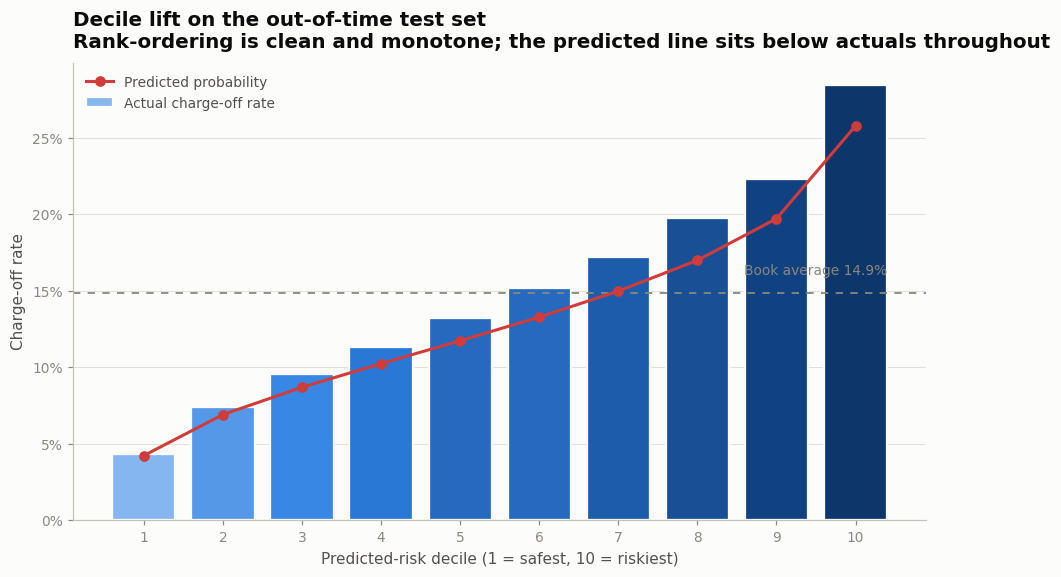

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.4))

x = np.arange(len(lift))
bars = ax.bar(x, lift["Actual_rate"], color=pl.ordinal_colors(len(lift)),
              edgecolor=pl.SURFACE, linewidth=1.5, label="Actual charge-off rate")
ax.plot(x, lift["Mean_PD"], color=pl.STATUS_CRITICAL, marker="o", markersize=6,
        label="Predicted probability", zorder=5)

ax.axhline(y_test.mean(), color=pl.INK_MUTED, linewidth=1.2, linestyle=(0, (4, 4)))
ax.text(9.4, y_test.mean() + 0.012, f"Book average {y_test.mean():.1%}",
        ha="right", fontsize=9, color=pl.INK_MUTED)

ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in lift.index])
ax.set_xlabel("Predicted-risk decile (1 = safest, 10 = riskiest)")
ax.set_ylabel("Charge-off rate")
ax.set_title(
    "Decile lift on the out-of-time test set\n"
    "Rank-ordering is clean and monotone; the predicted line sits below actuals throughout",
    loc="left",
)
pl.pct_axis(ax, decimals=0)
pl.style_axes(ax)
ax.legend(loc="upper left")

pl.save_fig(fig, "04_decile_lift.png")
plt.show()

The two things to take from this chart:

1. **The ordering is clean.** Every decile is worse than the one before it, with
   no inversions, on cohorts the model never saw. A score that ranks reliably out
   of time is usable for a cutoff or a pricing tier even when its level needs
   resetting.
2. **The gap between the line and the bars is the calibration problem, drawn.**
   It is roughly constant in relative terms across the deciles — which is what
   makes it fixable with a single recalibration factor rather than a refit.

## Saving the scored test set

Notebook 05 needs loan-level PDs to simulate portfolio loss, so we persist them.

In [15]:
scored_path = dp.PROCESSED.parent / "scored_test.parquet"
test_df[
    ["issue_d", "vintage_year", "grade", "fico_band", "term_months", "funded_amnt",
     "charged_off", "net_chargeoff", "lgd", "pd_pred", "decile"]
].to_parquet(scored_path, index=False)

print(f"Wrote {len(test_df):,} scored loans -> {scored_path.name}")
print(f"Test-set exposure: ${test_df['funded_amnt'].sum()/1e9:.2f}B")

Wrote 333,721 scored loans -> scored_test.parquet
Test-set exposure: $4.32B


---
**Next:** `05_portfolio_tail.ipynb` — aggregate these loan-level probabilities
into a portfolio loss distribution and look at the tail.